In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

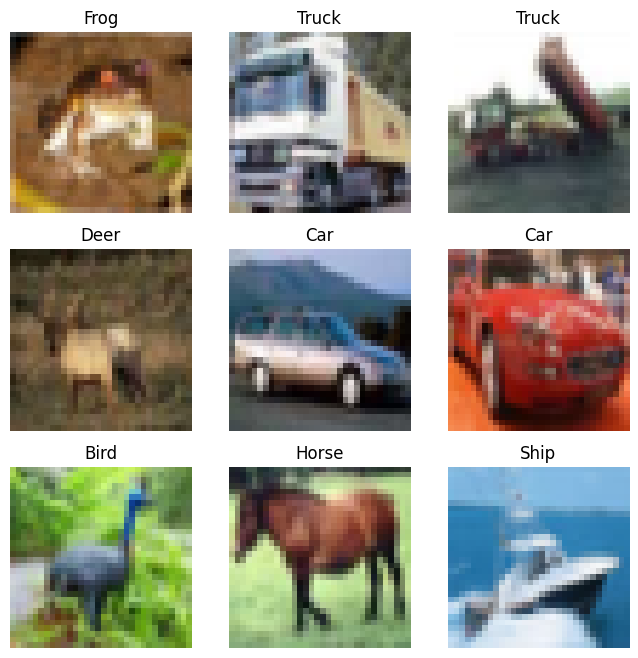

In [5]:
class_names = ['Airplane','Car','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [6]:
model = models.Sequential()

# 1st Convolution Layer
model.add(layers.Conv2D(32, (3,3), activation='relu',
                        input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

# 2nd Convolution Layer
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# 3rd Convolution Layer
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Flatten
model.add(layers.Flatten())

# Dense Layers
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    x_train, y_train,
    epochs=3,
    validation_data=(x_test, y_test)
)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.6692 - loss: 0.9381 - val_accuracy: 0.6671 - val_loss: 0.9417
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7004 - loss: 0.8539 - val_accuracy: 0.6809 - val_loss: 0.9201
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.7224 - loss: 0.7902 - val_accuracy: 0.6905 - val_loss: 0.9009


In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6957 - loss: 0.8857
Test Accuracy: 0.690500020980835


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
Predicted: Frog
Actual: Frog


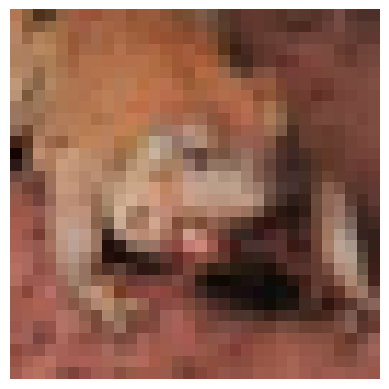

In [11]:
prediction = model.predict(x_test)

index = 5   # any number 0–9999

plt.imshow(x_test[index])
plt.axis('off')

print("Predicted:", class_names[np.argmax(prediction[index])])
print("Actual:", class_names[y_test[index][0]])